# Non-equilibrium Green's function formalism

`Heterostructure.didv`/`.landauer` are themselves built on the non-equilibrium (Keldysh) Green's
function machinery: each lead contributes a retarded self-energy $\Sigma_{L,R}(E)$
(`ht.get_selfenergy`, obtained by Green's-function renormalization/decimation -- see the spectral
functions section), from which the linewidth (coupling) matrices
$\Gamma_{L,R}=i(\Sigma_{L,R}-\Sigma_{L,R}^\dagger)$ and the retarded central Green's function
$G^r(E)=\left[(E+i\delta)\mathbb{1}-H_C-\Sigma_L-\Sigma_R\right]^{-1}$ follow directly. The
transmission is then the Caroli/Meir-Wingreen formula
$T(E)=\mathrm{Tr}\left[\Gamma_R\,G^r\,\Gamma_L\,G^{r\dagger}\right]$. Below, this formula is built
by hand from `ht.get_selfenergy` and checked against `ht.landauer(e)` directly.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

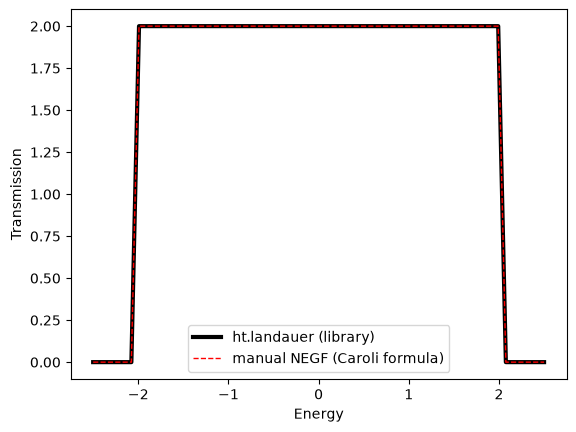

Max difference between the manual NEGF construction and ht.landauer: 0.0


In [2]:
from pyqula import algebra

g = geometry.chain()
gc = g.get_supercell(5)
gc.dimensionality = 0
hc = gc.get_hamiltonian()
h_normal = g.get_hamiltonian()
nsites = len(gc.r)
ht = hc.get_central_heterostructure(0,nsites-1,left=h_normal,right=h_normal)
ht.delta = 1e-6

def negf_transmission(e):
    delta = ht.delta
    intra = ht.central_intra
    iden = np.identity(intra.shape[0],dtype=complex)
    selfl = ht.get_selfenergy(e,lead=0,delta=delta,pristine=False)
    selfr = ht.get_selfenergy(e,lead=1,delta=delta,pristine=False)
    gammal = 1j*(selfl-algebra.dagger(selfl)) # left linewidth matrix
    gammar = 1j*(selfr-algebra.dagger(selfr)) # right linewidth matrix
    Gr = algebra.inv((e+1j*delta)*iden - (intra+selfl+selfr)) # retarded Green function
    Ga = algebra.dagger(Gr) # advanced Green function
    return np.trace(gammar@Gr@gammal@Ga).real # Caroli/Meir-Wingreen transmission

es = np.linspace(-2.5,2.5,60)
T_manual = [negf_transmission(e) for e in es]
T_landauer = [ht.landauer(e) for e in es]

plt.plot(es,T_landauer,c="black",lw=3,label="ht.landauer (library)")
plt.plot(es,T_manual,c="red",lw=1,ls="--",label="manual NEGF (Caroli formula)")
plt.xlabel("Energy") ; plt.ylabel("Transmission")
plt.legend()
plt.show()

print("Max difference between the manual NEGF construction and ht.landauer:",
      np.max(np.abs(np.array(T_manual)-np.array(T_landauer))))